In [1]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/cbb.csv")

In [3]:
df.describe()

,G,W,ADJOE,ADJDE,BARTHAG,EFG_O,EFG_D,TOR,TORD,ORB,...,FTR,FTRD,2P_O,2P_D,3P_O,3P_D,ADJ_T,WAB,SEED,YEAR
count,4249.000000,4249.000000,4249.000000,4249.000000,4249.000000,4249.000000,4249.000000,4249.000000,4249.000000,4249.000000,...,4249.000000,4249.000000,4249.000000,4249.000000,4249.000000,4249.000000,4249.000000,4249.000000,816.000000,4249.000000
mean,30.753589,16.177924,103.625865,103.627418,0.493439,50.006354,50.197670,18.441469,18.373923,29.302283,...,34.266486,34.523253,49.372747,49.534079,34.102189,34.279901,67.694493,-7.706672,8.797794,2018.968699
std,3.758512,6.497419,7.402858,6.563856,0.255445,3.080054,2.845484,2.160366,2.312224,4.201140,...,5.410060,6.266241,3.458268,3.311366,2.693363,2.387139,2.990581,6.870747,4.670970,3.892531
min,5.000000,0.000000,76.600000,84.000000,0.005000,39.200000,39.600000,11.900000,10.200000,14.400000,...,19.600000,16.200000,37.700000,37.700000,24.700000,26.100000,57.200000,-25.200000,1.000000,2013.000000
25%,29.000000,11.000000,98.600000,99.000000,0.281200,48.000000,48.300000,17.000000,16.800000,26.500000,...,30.500000,30.000000,47.000000,47.300000,32.300000,32.700000,65.700000,-12.800000,5.000000,2016.000000
50%,31.000000,16.000000,103.300000,103.800000,0.472500,50.000000,50.200000,18.300000,18.300000,29.400000,...,34.000000,33.900000,49.300000,49.500000,34.100000,34.200000,67.600000,-8.100000,9.000000,2019.000000
75%,33.000000,21.000000,108.300000,108.300000,0.715300,52.000000,52.100000,19.800000,19.800000,32.100000,...,37.700000,38.500000,51.600000,51.800000,35.900000,35.800000,69.600000,-3.100000,13.000000,2023.000000
max,40.000000,38.000000,130.600000,125.300000,0.984200,61.000000,60.100000,27.100000,28.500000,43.600000,...,58.600000,60.700000,64.000000,61.200000,44.100000,43.100000,83.400000,13.100000,16.000000,2025.000000


In [4]:
print(df.columns.tolist())
# ['TEAM', 'CONF', 'G', 'W', 'ADJOE', 'ADJDE', 'BARTHAG', 'EFG_O', 'EFG_D', 'TOR', 'TORD', 'ORB', 'DRB', 'FTR', 'FTRD', '2P_O', '2P_D', '3P_O', '3P_D', 'ADJ_T', 'WAB', 'POSTSEASON', 'SEED', 'YEAR']


['TEAM', 'CONF', 'G', 'W', 'ADJOE', 'ADJDE', 'BARTHAG', 'EFG_O', 'EFG_D', 'TOR', 'TORD', 'ORB', 'DRB', 'FTR', 'FTRD', '2P_O', '2P_D', '3P_O', '3P_D', 'ADJ_T', 'WAB', 'POSTSEASON', 'SEED', 'YEAR']


['TEAM', 'CONF', 'G', 'W', 'ADJOE', 'ADJDE', 'BARTHAG', 'EFG_O', 'EFG_D', 'TOR', 'TORD', 'ORB', 'DRB', 'FTR', 'FTRD', '2P_O', '2P_D', '3P_O', '3P_D', 'ADJ_T', 'WAB', 'POSTSEASON', 'SEED', 'YEAR']
Effective Field Goal % (EFG_O)
Turnover % (TOR)
Offensive Rebound % (ORB)
Free Throw Rate (FTR)

She specifically wants to compare the slopes of the regression
lines to see how these relationships change over time.

Task: Create similar visualizations in the next four slides

In [5]:
# run this by itself to run r 
%load_ext rpy2.ipython

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'



Attaching package: 'dplyr'

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union



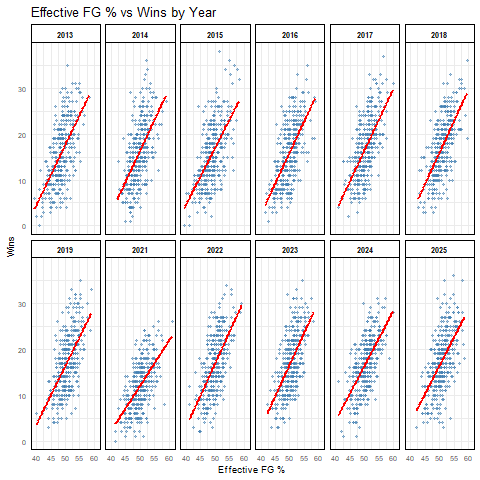

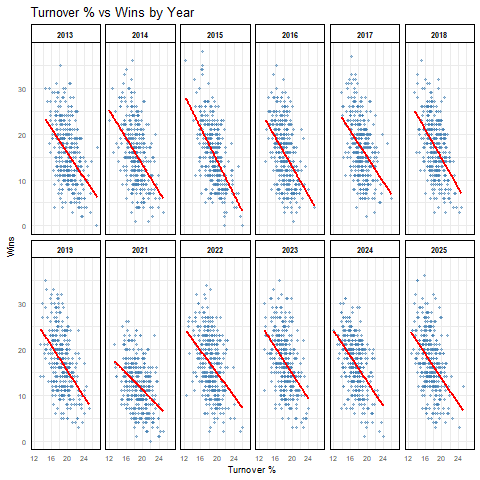

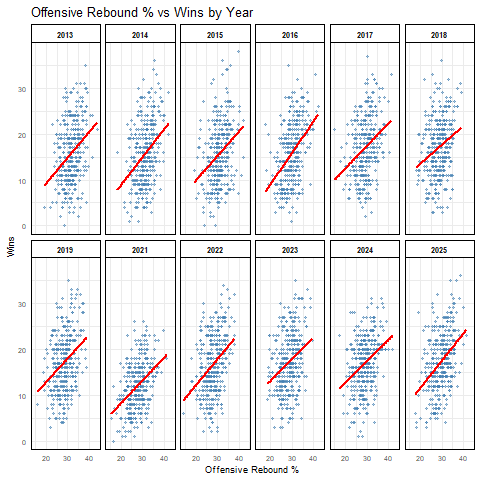

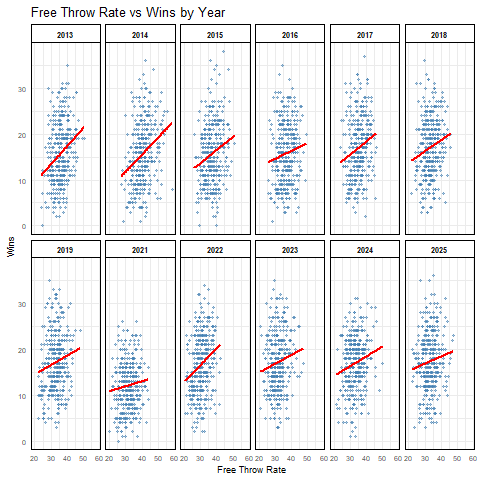

In [6]:
%%R -i df
library(dplyr)
library(ggplot2)

# Common theme
facet_theme <- theme_minimal() +
  theme(
    strip.background = element_rect(fill = "white", color = "black"),
    strip.text = element_text(size = 8, face = "bold"),
    axis.title = element_text(size = 9),
    axis.text = element_text(size = 7),
    panel.border = element_rect(color = "black", fill = NA)
  )

# 1. Effective Field Goal % vs Wins
p1 <- ggplot(df, aes(x = EFG_O, y = W)) +
  geom_point(color = "steelblue", alpha = 0.5, size = 1) +
  geom_smooth(method = "lm", color = "red", se = FALSE) +
  facet_wrap(~ YEAR, ncol = 6) +
  labs(title = "Effective FG % vs Wins by Year",
       x = "Effective FG %", y = "Wins") +
  facet_theme

# 2. Turnover % vs Wins
p2 <- ggplot(df, aes(x = TOR, y = W)) +
  geom_point(color = "steelblue", alpha = 0.5, size = 1) +
  geom_smooth(method = "lm", color = "red", se = FALSE) +
  facet_wrap(~ YEAR, ncol = 6) +
  labs(title = "Turnover % vs Wins by Year",
       x = "Turnover %", y = "Wins") +
  facet_theme

# 3. Offensive Rebound % vs Wins
p3 <- ggplot(df, aes(x = ORB, y = W)) +
  geom_point(color = "steelblue", alpha = 0.5, size = 1) +
  geom_smooth(method = "lm", color = "red", se = FALSE) +
  facet_wrap(~ YEAR, ncol = 6) +
  labs(title = "Offensive Rebound % vs Wins by Year",
       x = "Offensive Rebound %", y = "Wins") +
  facet_theme

# 4. Free Throw Rate vs Wins
p4 <- ggplot(df, aes(x = FTR, y = W)) +
  geom_point(color = "steelblue", alpha = 0.5, size = 1) +
  geom_smooth(method = "lm", color = "red", se = FALSE) +
  facet_wrap(~ YEAR, ncol = 6) +
  labs(title = "Free Throw Rate vs Wins by Year",
       x = "Free Throw Rate", y = "Wins") +
  facet_theme

# Print all four
print(p1)
print(p2)
print(p3)
print(p4)

In [8]:
%%R -i df
library(dplyr)

vars <- c("EFG_O", "TOR", "ORB", "FTR")
years <- sort(unique(df$YEAR))

slope_results <- data.frame(Variable = character(), YEAR = numeric(), Slope = numeric())

for (v in vars) {
  for (y in years) {
    sub_df <- df[df$YEAR == y, ]
    
    # Skip if not enough data
    if (nrow(sub_df) < 3) next
    
    slope <- coef(lm(as.formula(paste("W ~", v)), data = sub_df))[2]
    
    slope_results <- rbind(slope_results, data.frame(
      Variable = v,
      YEAR     = y,
      Slope    = round(slope, 4)
    ))
  }
}

print(slope_results)

        Variable YEAR   Slope
EFG_O      EFG_O 2013  1.3130
EFG_O1     EFG_O 2014  1.3457
EFG_O2     EFG_O 2015  1.2324
EFG_O3     EFG_O 2016  1.3478
EFG_O4     EFG_O 2017  1.3400
EFG_O5     EFG_O 2018  1.3656
EFG_O6     EFG_O 2019  1.2746
EFG_O7     EFG_O 2021  0.9822
EFG_O8     EFG_O 2022  1.3808
EFG_O9     EFG_O 2023  1.3805
EFG_O10    EFG_O 2024  1.1963
EFG_O11    EFG_O 2025  1.2275
TOR          TOR 2013 -1.3524
TOR1         TOR 2014 -1.4757
TOR2         TOR 2015 -1.8096
TOR3         TOR 2016 -1.5825
TOR4         TOR 2017 -1.3957
TOR5         TOR 2018 -1.5946
TOR6         TOR 2019 -1.4106
TOR7         TOR 2021 -0.9321
TOR8         TOR 2022 -1.2313
TOR9         TOR 2023 -1.3957
TOR10        TOR 2024 -1.3701
TOR11        TOR 2025 -1.3632
ORB          ORB 2013  0.5619
ORB1         ORB 2014  0.6102
ORB2         ORB 2015  0.5366
ORB3         ORB 2016  0.6883
ORB4         ORB 2017  0.4920
ORB5         ORB 2018  0.4155
ORB6         ORB 2019  0.5175
ORB7         ORB 2021  0.4980
ORB8      

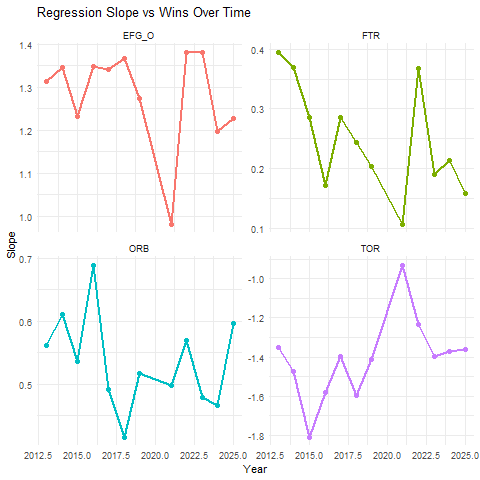

In [9]:
%%R -i df
library(ggplot2)

ggplot(slope_results, aes(x = YEAR, y = Slope, color = Variable, group = Variable)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  facet_wrap(~ Variable, scales = "free_y", ncol = 2) +
  labs(title = "Regression Slope vs Wins Over Time",
       x = "Year", y = "Slope") +
  theme_minimal() +
  theme(legend.position = "none")